In [1]:
# Packages
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Loading the data
metadata = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/metadata.csv")
meth = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/DNAm.csv")
cnv = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/cnv.csv")
rna = pd.read_csv("/Users/in2245sa/Courses/medbioinfo/systems_biology/group_project/Group3-TCGA-KIRC-renal/RNASeq.csv")

In [3]:
# Use sample names as rownames in metadaata
metadata = metadata.set_index("patient_id")

# Reformat sample names
cnv["sample_id"] = cnv["sample_id"].str.replace(".", "-", regex=False)
rna["sample_id"] = rna["sample_id"].str.replace(".", "-", regex=False)
meth["sample_id"] = meth["sample_id"].str.replace(".", "-", regex=False)

def shorten_tcga_id(x):
    
    parts = x.split("-")
    # TCGA barcode structure: sample-level ends at element 4
    # if there are more parts → strip last two
    if len(parts) > 4:
        return "-".join(parts[:4])
    return x

cnv["sample_id"] = cnv["sample_id"].apply(shorten_tcga_id)
rna["sample_id"] = rna["sample_id"].apply(shorten_tcga_id)
meth["sample_id"] = meth["sample_id"].apply(shorten_tcga_id)

In [4]:
meth_ids = metadata.index[
    (metadata["label"] == 1) &
    (metadata["has_DNAm"] == True) &
    (metadata["has_RNASeq"] == False) &
    (metadata["has_CNV"] == False)
].to_list()

rna_cnv_ids = metadata.index[
    (metadata["label"] == 1) &
    (metadata["has_DNAm"] == False) &
    (metadata["has_RNASeq"] == True) &
    (metadata["has_CNV"] == True)
].to_list()

n = min(len(meth_ids), len(rna_cnv_ids))
meth_ids = meth_ids[:n]
rna_cnv_ids = rna_cnv_ids[:n]

paired_dict = dict(zip(meth_ids, rna_cnv_ids))


In [45]:
#FAKING DATA. 
meth["sample_id"] = meth["sample_id"].replace(paired_dict)

In [47]:
# Copying preselected genes
top_genes_df = pd.read_csv("top_genes_multiomics.csv")

top_genes_GEX = top_genes_df["GEX"].dropna()
top_genes_METH = top_genes_df["METH"].dropna()
top_genes_CNV = top_genes_df["CNV"].dropna()

In [48]:
# Reformat sample names
cnv["sample_id"] = cnv["sample_id"].str.replace(".", "-", regex=False)
rna["sample_id"] = rna["sample_id"].str.replace(".", "-", regex=False)
meth["sample_id"] = meth["sample_id"].str.replace(".", "-", regex=False)

def shorten_tcga_id(x):
    
    parts = x.split("-")
    # TCGA barcode structure: sample-level ends at element 4
    # if there are more parts → strip last two
    if len(parts) > 4:
        return "-".join(parts[:4])
    return x

cnv["sample_id"] = cnv["sample_id"].apply(shorten_tcga_id)
rna["sample_id"] = rna["sample_id"].apply(shorten_tcga_id)
meth["sample_id"] = meth["sample_id"].apply(shorten_tcga_id)

In [49]:
# CNV + RNA

# Finding overlapping samples
overlap_cnv_rna = sorted(set(cnv["sample_id"]) & set(rna["sample_id"]))

rna_filtered = (
    rna[rna["sample_id"].isin(overlap_cnv_rna)]
    .set_index("sample_id")
)

cnv_filtered = (
    cnv[cnv["sample_id"].isin(overlap_cnv_rna)]
    .set_index("sample_id")
)

# Align explicitly
rna_filtered = rna_filtered.loc[overlap_cnv_rna, top_genes_GEX]
cnv_filtered = cnv_filtered.loc[overlap_cnv_rna, top_genes_CNV]

# Concatenate
cnv_prefixed = cnv_filtered.add_prefix("CNV_")
rna_prefixed = rna_filtered.add_prefix("RNA_")

combined = pd.concat([cnv_prefixed, rna_prefixed], axis=1)

In [50]:
# Split training & test data
from sklearn.model_selection import train_test_split

X = combined
y = metadata.loc[overlap_cnv_rna, "label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [51]:
# Perform hyperparameter tuning C  values and l1_ratio
from sklearn.linear_model import LogisticRegressionCV
logreg_cv = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[0.1, 0.5, 0.9],
    max_iter=10000,
    random_state=42
)
logreg_cv.fit(X_train, y_train)

/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
 

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0.1, 0.5, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the mul

In [52]:
# Visualize the best C and l1_ratio
best_C = logreg_cv.C_[0]
best_l1_ratio = logreg_cv.l1_ratio_[0]

print(f"Best C: {best_C}")
print(f"Best l1_ratio: {best_l1_ratio}")

Best C: 0.046415888336127774
Best l1_ratio: 0.1


In [53]:
# Set up the pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("clf", LogisticRegression(
        solver = "saga",
        penalty="elasticnet",
        max_iter=100,
        class_weight="balanced",
        C=0.5,
        l1_ratio=0.75
    ))
])

In [55]:
# Train the model
pipeline.fit(X_train, y_train)

/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.5
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.75
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueS

In [56]:
# Evaluate the model
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       1.00      1.00      1.00        57

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70

ROC-AUC: 1.0


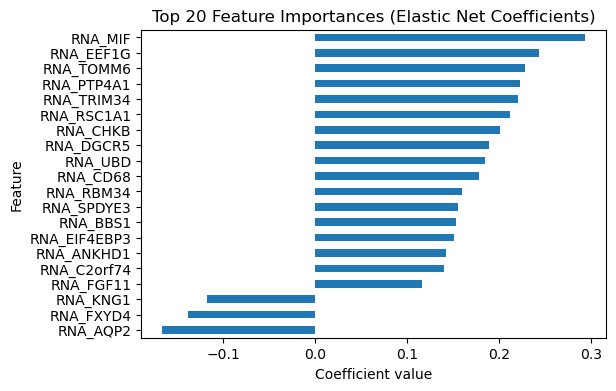

In [57]:
model = pipeline.named_steps["clf"]

import pandas as pd

importance = pd.Series(
    model.coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

top20 = importance.head(20)
plt.figure(figsize=(6, 4))
top20.sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances (Elastic Net Coefficients)")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.show()

In [58]:
# Check how many RNA and CNV features are in the top 20 and top 100
top20 = importance.head(20)
top100 = importance.head(100)
print("Top 20:")
print("RNA features:", sum(top20.index.str.startswith("RNA_")))
print("CNV features:", sum(top20.index.str.startswith("CNV_")))
print("\nTop 100:")
print("RNA features:", sum(top100.index.str.startswith("RNA_")))
print("CNV features:", sum(top100.index.str.startswith("CNV_")))

Top 20:
RNA features: 20
CNV features: 0

Top 100:
RNA features: 100
CNV features: 0


/var/folders/s0/5zs20v2s4wg25w78s5tjjvyc0000gp/T/ipykernel_30324/1309238705.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


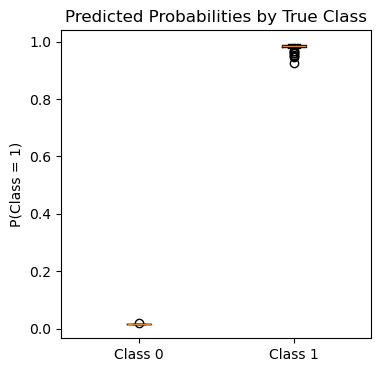

In [59]:
probs = pipeline.predict_proba(X_test)[:, 1]

plt.figure(figsize=(4, 4))

plt.boxplot(
    [probs[y_test == 0], probs[y_test == 1]],
    labels=["Class 0", "Class 1"],
    showfliers=True
)

plt.title("Predicted Probabilities by True Class")
plt.ylabel("P(Class = 1)")
plt.show()

In [60]:
# CNV + METHYLATION

# Finding overlapping samples
overlap_cnv_meth = sorted(set(cnv["sample_id"]) & set(meth["sample_id"]))

meth_filtered = (
    meth[meth["sample_id"].isin(overlap_cnv_meth)]
    .set_index("sample_id")
)

cnv_filtered = (
    cnv[cnv["sample_id"].isin(overlap_cnv_rna)]
    .set_index("sample_id")
)

# Align explicitly
meth_filtered = meth_filtered.loc[overlap_cnv_meth, top_genes_METH]
cnv_filtered = cnv_filtered.loc[overlap_cnv_meth, top_genes_CNV]

# Concatenate
cnv_prefixed = cnv_filtered.add_prefix("CNV_")
meth_prefixed = meth_filtered.add_prefix("METH_")

combined = pd.concat([cnv_prefixed, meth_prefixed], axis=1)

In [43]:
# Split training & test data
from sklearn.model_selection import train_test_split

X = combined
y = metadata.loc[overlap_cnv_meth, "label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [61]:
# Perform hyperparameter tuning C  values and l1_ratio
from sklearn.linear_model import LogisticRegressionCV
logreg_cv = LogisticRegressionCV(
    Cs=10,
    cv=5,
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[0.1, 0.5, 0.9],
    max_iter=10000,
    random_state=42
)
logreg_cv.fit(X_train, y_train)

/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegressionCV for more details.
 

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.","[0.1, 0.5, ...]"
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the mul

In [62]:
# Visualize the best C and l1_ratio
best_C = logreg_cv.C_[0]
best_l1_ratio = logreg_cv.l1_ratio_[0]

print(f"Best C: {best_C}")
print(f"Best l1_ratio: {best_l1_ratio}")

Best C: 0.046415888336127774
Best l1_ratio: 0.1


In [33]:
# Set up the pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("clf", LogisticRegression(
        solver = "saga",
        penalty="elasticnet",
        max_iter=100,
        class_weight="balanced",
        C=0.75,
        l1_ratio=0.75
    ))
])

In [34]:
# Train the model
pipeline.fit(X_train, y_train)

/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.75
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.75
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=True

In [35]:
# Evaluate the model
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        57

    accuracy                           1.00        62
   macro avg       1.00      1.00      1.00        62
weighted avg       1.00      1.00      1.00        62

ROC-AUC: 1.0


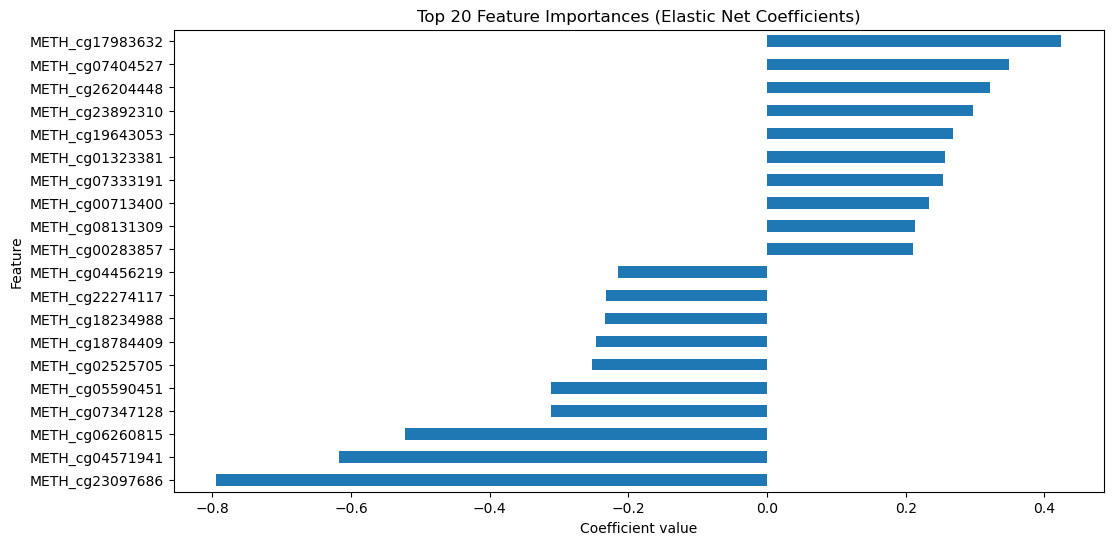

In [36]:
model = pipeline.named_steps["clf"]

import pandas as pd

importance = pd.Series(
    model.coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

top20 = importance.head(20)
plt.figure(figsize=(12, 6))
top20.sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances (Elastic Net Coefficients)")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.show()

/var/folders/s0/5zs20v2s4wg25w78s5tjjvyc0000gp/T/ipykernel_16494/1239857530.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


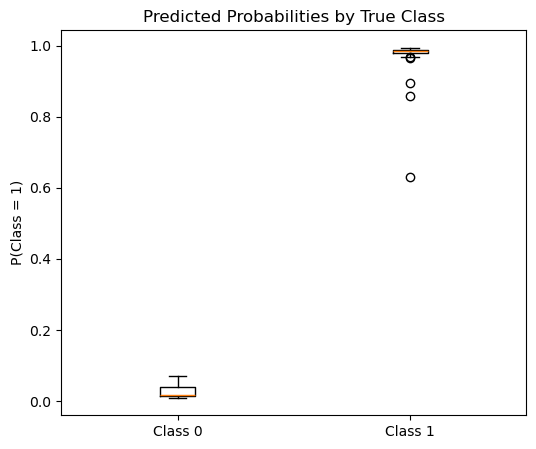

In [37]:
probs = pipeline.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6, 5))

plt.boxplot(
    [probs[y_test == 0], probs[y_test == 1]],
    labels=["Class 0", "Class 1"],
    showfliers=True
)

plt.title("Predicted Probabilities by True Class")
plt.ylabel("P(Class = 1)")
plt.show()

In [38]:
# RNA + METHYLATION

# Finding overlapping samples
overlap_rna_meth = sorted(set(rna["sample_id"]) & set(meth["sample_id"]))

meth_filtered = (
    meth[meth["sample_id"].isin(overlap_rna_meth)]
    .set_index("sample_id")
)

rna_filtered = (
    rna[rna["sample_id"].isin(overlap_rna_meth)]
    .set_index("sample_id")
)

# Align explicitly
meth_filtered = meth_filtered.loc[overlap_rna_meth, top_genes_METH]
rna_filtered = rna_filtered.loc[overlap_rna_meth, top_genes_GEX]

# Concatenate
rna_prefixed = rna_filtered.add_prefix("RNA_")
meth_prefixed = meth_filtered.add_prefix("METH_")

combined = pd.concat([rna_prefixed, meth_prefixed], axis=1)
print(combined.shape)

(310, 1000)


In [39]:
# Split training & test data
from sklearn.model_selection import train_test_split

X = combined
y = metadata.loc[overlap_cnv_meth, "label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [40]:
# Set up the pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("clf", LogisticRegression(
        solver = "saga",
        penalty="elasticnet",
        max_iter=100,
        class_weight="balanced",
        C=0.75,
        l1_ratio=0.75
    ))
])

In [41]:
# Train the model
pipeline.fit(X_train, y_train)

/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.75
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.75
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=True

In [24]:
# Evaluate the model
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [23]:
model = pipeline.named_steps["clf"]

import pandas as pd

importance = pd.Series(
    model.coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

top20 = importance.head(20)
plt.figure(figsize=(12, 6))
top20.sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances (Elastic Net Coefficients)")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.show()

AttributeError: 'LogisticRegression' object has no attribute 'coef_'

In [22]:
probs = pipeline.predict_proba(X_test)[:, 1]

plt.figure(figsize=(3, 2))

plt.boxplot(
    [probs[y_test == 0], probs[y_test == 1]],
    labels=["Class 0", "Class 1"],
    showfliers=True
)

plt.title("Predicted Probabilities by True Class")
plt.ylabel("P(Class = 1)")
plt.show()

NotFittedError: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [46]:
# CNV + METHYLATION + RNA

# Finding overlapping samples
overlap_all = sorted(set(cnv["sample_id"]) & set(meth["sample_id"]) & set(rna["sample_id"]))

meth_filtered = (
    meth[meth["sample_id"].isin(overlap_all)]
    .set_index("sample_id")
)

cnv_filtered = (
    cnv[cnv["sample_id"].isin(overlap_all)]
    .set_index("sample_id")
)

rna_filtered = (
    rna[rna["sample_id"].isin(overlap_all)]
    .set_index("sample_id")
)

# Align explicitly
meth_filtered = meth_filtered.loc[overlap_all, top_genes_METH]
cnv_filtered = cnv_filtered.loc[overlap_all, top_genes_CNV]
rna_filtered = rna_filtered.loc[overlap_all, top_genes_GEX]

# Concatenate
cnv_prefixed = cnv_filtered.add_prefix("CNV_")
meth_prefixed = meth_filtered.add_prefix("METH_")
rna_prefixed = rna_filtered.add_prefix("RNA_")

combined = pd.concat([cnv_prefixed, meth_prefixed, rna_prefixed], axis=1)

In [47]:
# Split training & test data
from sklearn.model_selection import train_test_split

X = combined
y = metadata.loc[overlap_cnv_meth, "label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [48]:
# Set up the pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("clf", LogisticRegression(
        solver = "saga",
        penalty="elasticnet",
        max_iter=100,
        class_weight="balanced",
        C=0.1,
        l1_ratio=0.75
    ))
])

In [49]:
# Train the model
pipeline.fit(X_train, y_train)

/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/in2245sa/miniconda3/envs/SysCompBio_2026_env/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'elasticnet'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.75
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueS

In [50]:
# Evaluate the model
from sklearn.metrics import classification_report, roc_auc_score

y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        57

    accuracy                           1.00        62
   macro avg       1.00      1.00      1.00        62
weighted avg       1.00      1.00      1.00        62

ROC-AUC: 1.0


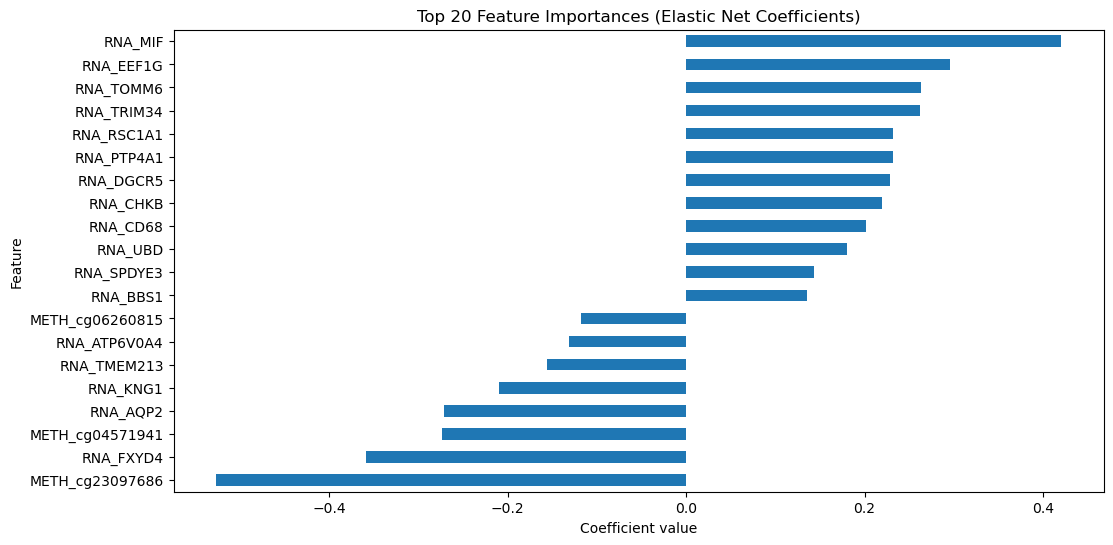

In [51]:
model = pipeline.named_steps["clf"]

import pandas as pd

importance = pd.Series(
    model.coef_[0],
    index=X_train.columns
).sort_values(key=abs, ascending=False)

top20 = importance.head(20)
plt.figure(figsize=(12, 6))
top20.sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances (Elastic Net Coefficients)")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.show()

/var/folders/s0/5zs20v2s4wg25w78s5tjjvyc0000gp/T/ipykernel_16494/1239857530.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


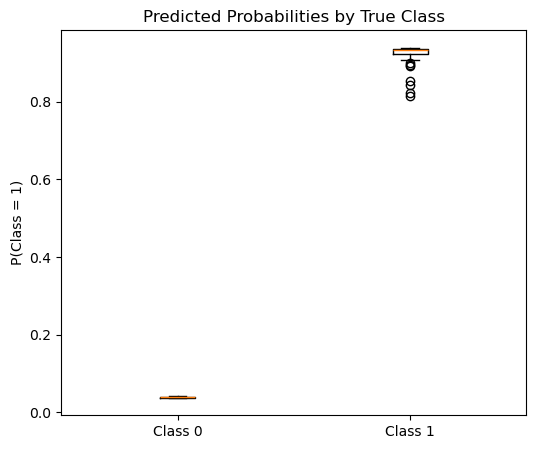

In [52]:
probs = pipeline.predict_proba(X_test)[:, 1]

plt.figure(figsize=(6, 5))

plt.boxplot(
    [probs[y_test == 0], probs[y_test == 1]],
    labels=["Class 0", "Class 1"],
    showfliers=True
)

plt.title("Predicted Probabilities by True Class")
plt.ylabel("P(Class = 1)")
plt.show()